# Synthetic control for a policy evaluation: two routes to inference

One state adopts a **clean-energy standard** in a single quarter, and you want its
effect on **per-capita renewable electricity generation**. There is no clean control
group — no other state is a perfect twin of the one that acted. The *synthetic control
method* (Abadie, Diamond & Hainmueller 2010) solves this by **building** a counterfactual:
a weighted blend of untreated "donor" states chosen to track the treated state's
pre-policy trajectory. The post-policy gap between the real state and its synthetic twin
is the estimated effect.

The catch: with a single treated unit there is **no analytical standard error** — in
`diff-diff`, `SyntheticControl`'s `se`, `t_stat`, `p_value`, and `conf_int` are `NaN` by
design. Inference instead comes from one of two genuinely different places, and this
tutorial walks **both**:

- **Philosophy A — compare across regions** (permutation): is the treated state's gap
  unusual relative to pretending *each donor* had adopted the policy? This is the
  in-space placebo (ADH 2010) and the Firpo–Possebom (2018) confidence set.
- **Philosophy B — compare across time** (conformal): Chernozhukov, Wüthrich & Zhu (2021)
  invert a permutation-over-time test to produce a valid p-value for a hypothesized effect
  *path* and a **confidence interval for each post-period** — something cross-region
  permutation cannot give.

We generate a synthetic panel where the truth is known, so every diagnostic can be checked
against the right answer.

## The setup

We use `generate_synthetic_control_data`, which builds a factor-model panel with **one
treated unit (id `0`)** and a donor pool. The treated unit's latent factor loadings and
baseline are an exact convex combination of a few donors, so its **noiseless** trajectory
lies in the donor convex hull and a synthetic control can reproduce it closely — the
*observed* fit is approximate because we add transitory and predictor noise (so the
pre-period RMSPE is small but not exactly zero). A known **ramping** treatment effect
(`5, 6, 7, 8, 9`) is injected into the post period, mimicking a program that scales up as
it rolls out.

We use a long pre-period (60 quarters) and a short post-period (5 quarters): synthetic
control wants a long, well-matched pre-window, and — as we'll see in Philosophy B — the conformal
average-effect interval needs enough pre-period "blocks" to resolve.

In [1]:
%matplotlib inline
import warnings

import matplotlib.pyplot as plt
import numpy as np

from diff_diff import SyntheticControl, generate_synthetic_control_data

# On Apple-Silicon BLAS, harmless "invalid value encountered in matmul" RuntimeWarnings
# can surface from the optimizer; filter only that one (never UserWarnings, which carry
# methodology guidance). See numpy#28687.
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*encountered in matmul")

panel = generate_synthetic_control_data(
    n_donors=20,
    n_pre=60,
    n_post=5,
    n_factors=3,
    n_predictors=3,
    treatment_effect=5.0,   # first post-period effect
    effect_type="ramp",     # effect grows by effect_growth each post period
    effect_growth=1.0,
    noise_sd=0.6,
    seed=0,
)
print(f"panel: {len(panel)} rows | {panel['unit'].nunique()} units "
      f"(1 treated + 20 donors) | {panel['period'].nunique()} quarters")
panel.head()

panel: 1365 rows | 21 units (1 treated + 20 donors) | 65 quarters


,unit,period,outcome,treatment,treat,true_effect,x1,x2,x3
0,0,0,49.004867,0,1,0.0,0.505192,-0.399552,0.971594
1,0,1,49.380750,0,1,0.0,0.505192,-0.399552,0.971594
2,0,2,51.031864,0,1,0.0,0.505192,-0.399552,0.971594
3,0,3,50.231137,0,1,0.0,0.505192,-0.399552,0.971594
4,0,4,46.994405,0,1,0.0,0.505192,-0.399552,0.971594


Columns: `unit` (0 = the treated state), `period` (0–59 pre, 60–64 post),
`outcome` (per-capita renewable generation), `treatment` (absorbing 0/1 — `1` only for the
treated state in post quarters), `true_effect` (the injected effect, for grading), and
three pre-treatment covariates `x1, x2, x3` — think *industrial electricity demand*,
*renewable-resource quality*, and *installed capacity*. `SyntheticControl.fit` infers the
treated unit and the post window directly from `treatment`.

## Fit the synthetic control

`SyntheticControl` chooses **donor weights** (nonnegative, summing to one) so the synthetic
state matches the treated state on the predictors, and **predictor weights** `V` (via a
nested pre-period search) that decide how much each predictor matters. We pass the three
covariates as `predictors=` and use light solver settings to keep the notebook fast.

In [2]:
sc = SyntheticControl(
    v_method="nested",
    n_starts=1,
    inner_min_decrease=1e-3,
    optimizer_options={"maxiter": 50},
    seed=0,
)
res = sc.fit(
    panel,
    outcome="outcome",
    treatment="treatment",
    unit="unit",
    time="period",
    predictors=["x1", "x2", "x3"],
)
print(f"ATT (avg post-period gap): {res.att:.3f}")
print(f"pre-period RMSPE:          {res.pre_rmspe:.3f}")
print("\ntop donor weights:")
print(res.get_weights_df().head(5).to_string(index=False))
print("\npredictor weights (V):", {k: round(v, 3) for k, v in res.v_weights.items()})

ATT (avg post-period gap): 6.790
pre-period RMSPE:          0.987

top donor weights:
 unit   weight
    2 0.509414
    3 0.256761
   13 0.081908
   18 0.071077
   16 0.016055

predictor weights (V): {'x1': 0.461, 'x2': 0.081, 'x3': 0.458}


**Reading the fit.** The synthetic state is a *sparse* blend — a couple of donors
carry most of the weight (here roughly `0.51·unit 2 + 0.26·unit 3 + …`). The pre-period
RMSPE of about **0.99** is small relative to the `5`–`9` effect, so the synthetic tracks the
treated state closely *before* the policy. The average post-period gap is **≈ 6.8**, against a
true average of `7.0`.

**An honest caveat on the weights.** Do not read the weights as "the true recipe." With
many donors and few factors, *many* weightings reproduce the pre-period path equally well —
the weight vector is **not identified**. What synthetic control identifies is the
**counterfactual outcome path** (and hence the gap/ATT), not a unique set of weights.

In [3]:
# Predictor balance: does the synthetic state look like the treated state on the
# covariates? Compare to the raw donor-pool average.
res.predictor_balance.round(3)

,predictor,treated,synthetic,donor_mean
0,x1,0.505,0.506,0.028
1,x2,-0.400,-0.363,0.298
2,x3,0.972,0.975,0.545


**Balance check.** The synthetic state matches the treated state almost exactly on
all three covariates (the `treated` and `synthetic` columns nearly coincide), while the raw
`donor_mean` is noticeably off. That is the whole point of weighting: a *plain* average of
donors is a poor comparison, but the *weighted* synthetic is a close one.

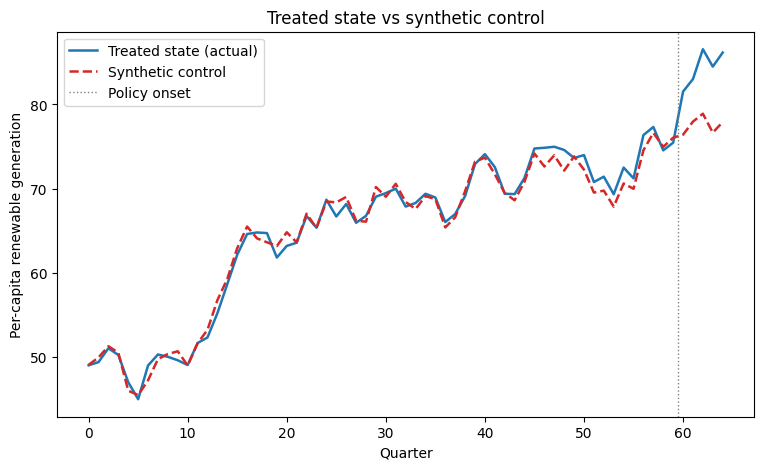

In [4]:
# Plot 1: the treated state vs its synthetic counterfactual.
gd = res.get_gap_df().sort_values("period")
periods = gd["period"].to_numpy()
treated_y = panel[panel["unit"] == 0].sort_values("period")["outcome"].to_numpy()
synth_y = treated_y - gd["gap"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(periods, treated_y, color="#1f77b4", lw=1.8, label="Treated state (actual)")
ax.plot(periods, synth_y, color="#d62728", lw=1.8, ls="--", label="Synthetic control")
ax.axvline(59.5, color="gray", ls=":", lw=1, label="Policy onset")
ax.set_xlabel("Quarter")
ax.set_ylabel("Per-capita renewable generation")
ax.set_title("Treated state vs synthetic control")
ax.legend(loc="upper left")
plt.show()

## The effect path

The **gap** (treated − synthetic) is flat and near zero before the policy and opens up
after it. Overlaying the known `true_effect` shows the estimate recovers the ramp.

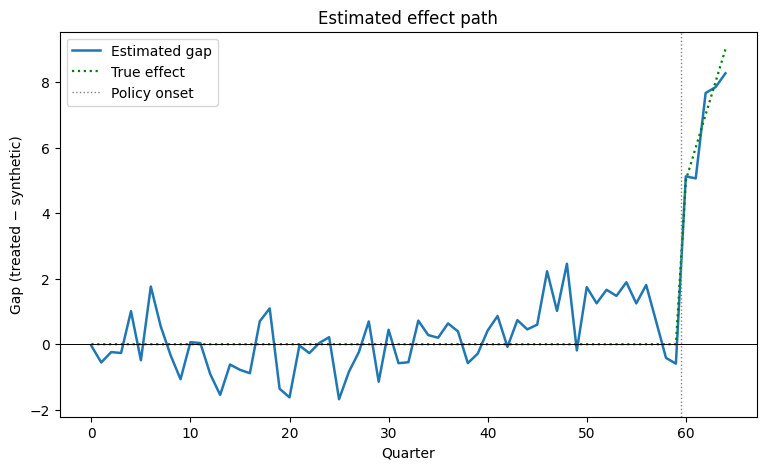

In [5]:
# Plot 2: estimated gap vs the true effect.
true_eff = panel[panel["unit"] == 0].sort_values("period")["true_effect"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(periods, gd["gap"].to_numpy(), color="#1f77b4", lw=1.8, label="Estimated gap")
ax.plot(periods, true_eff, color="green", lw=1.6, ls=":", label="True effect")
ax.axhline(0, color="black", lw=0.7)
ax.axvline(59.5, color="gray", ls=":", lw=1, label="Policy onset")
ax.set_xlabel("Quarter")
ax.set_ylabel("Gap (treated − synthetic)")
ax.set_title("Estimated effect path")
ax.legend(loc="upper left")
plt.show()

The pre-period gap hugs zero (good fit), and the post-period gap climbs roughly
`5 → 9`, tracking the truth. But a single treated unit gives us one realization — **is this
gap distinguishable from noise?** That is the inference question, and the rest of the
tutorial answers it two ways.

## Philosophy A — compare across regions

If the policy did nothing, the treated state's post/pre RMSPE ratio should look like what we
get by pretending *each donor* was treated. The **in-space placebo** (ADH 2010 §2.4) refits
the synthetic control with each donor cast as the "treated" unit and ranks the real treated
state's ratio against that placebo distribution.

In [6]:
placebo = res.in_space_placebo(n_starts=1)
print(f"placebo p-value: {res.placebo_p_value:.4f}")
print(f"treated post/pre RMSPE ratio: {res.rmspe_ratio:.2f} "
      f"(rank 1 of {res.n_placebos + 1})")

placebo p-value: 0.0476
treated post/pre RMSPE ratio: 7.03 (rank 1 of 21)


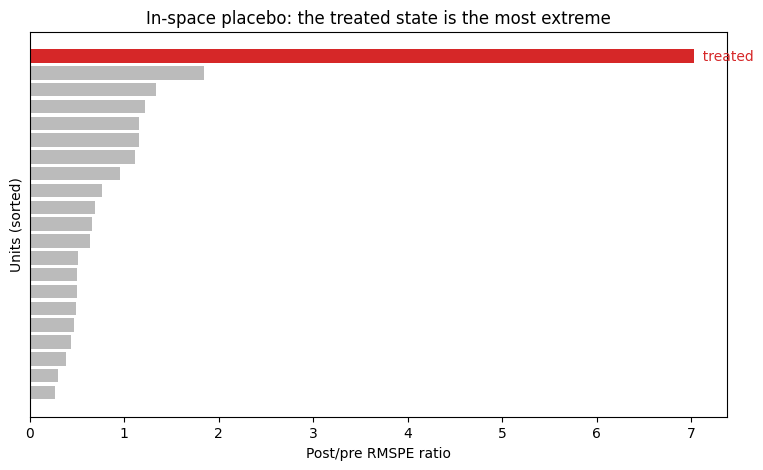

In [7]:
# Plot 3: the placebo distribution of post/pre RMSPE ratios (Abadie's plot).
pl = res.get_placebo_df().sort_values("rmspe_ratio")
colors = ["#d62728" if t else "#bbbbbb" for t in pl["is_treated"]]
labels = ["Treated state" if t else "" for t in pl["is_treated"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(pl)), pl["rmspe_ratio"], color=colors)
for y, (lab, t) in enumerate(zip(labels, pl["is_treated"])):
    if t:
        ax.text(pl["rmspe_ratio"].iloc[y], y, "  treated", va="center", color="#d62728")
ax.set_xlabel("Post/pre RMSPE ratio")
ax.set_ylabel("Units (sorted)")
ax.set_title("In-space placebo: the treated state is the most extreme")
ax.set_yticks([])
plt.show()

**Reading the placebo.** The treated state has the **largest** post/pre RMSPE ratio
of all 21 units, giving a permutation p-value of **≈ 0.048** — significant at the 5% level.
(With 20 donors the smallest achievable p-value is `1/21`; a larger donor pool would give a
finer p-value.)

The Firpo–Possebom (2018) **confidence set** inverts this placebo test over a family of
effect paths. The simplest family is a *constant* effect.

In [8]:
cs = res.confidence_set(family="constant", gamma=0.1)
in_set = cs[cs["in_set"]]
print(f"90% confidence set for a constant effect: "
      f"[{in_set['param'].min():.2f}, {in_set['param'].max():.2f}]")

90% confidence set for a constant effect: [4.05, 24.33]


**A rigid family.** The constant-effect set is wide and lopsided — because our effect
*ramps* rather than staying constant, a single constant value is a poor description, and the
test only rejects clearly-wrong constants. This is exactly the gap Philosophy B fills: a
per-period interval that needs no parametric effect-path assumption.

First, two standard robustness checks (ADH 2015).

max |change in ATT| when dropping any one donor: 0.761


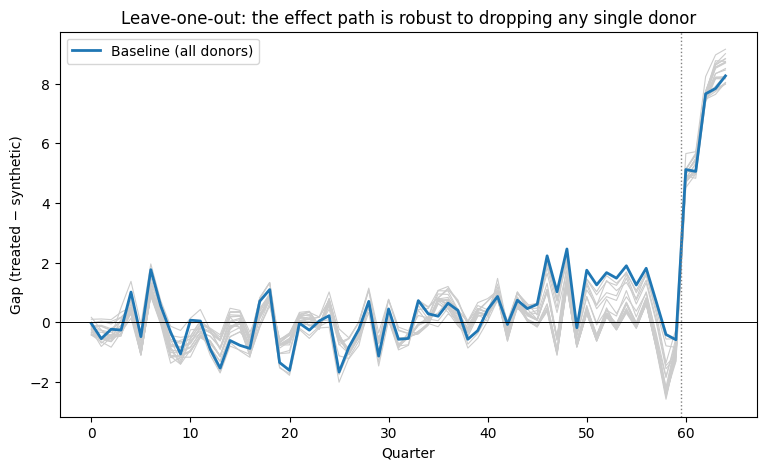

In [9]:
# Leave-one-out: drop each weighted donor and refit; how much does the gap move?
loo = res.leave_one_out(n_starts=1)
moved = loo[loo["status"] == "loo"]
print(f"max |change in ATT| when dropping any one donor: {moved['delta_att'].abs().max():.3f}")

# Plot 4: leave-one-out gap paths (spaghetti) around the baseline.
log = res.get_leave_one_out_gaps()
fig, ax = plt.subplots(figsize=(9, 5))
for _, sub in log.groupby("dropped_unit"):
    sub = sub.sort_values("period")
    ax.plot(sub["period"], sub["gap"], color="#cccccc", lw=0.8)
ax.plot(periods, gd["gap"].to_numpy(), color="#1f77b4", lw=2.0, label="Baseline (all donors)")
ax.axhline(0, color="black", lw=0.7)
ax.axvline(59.5, color="gray", ls=":", lw=1)
ax.set_xlabel("Quarter")
ax.set_ylabel("Gap (treated − synthetic)")
ax.set_title("Leave-one-out: the effect path is robust to dropping any single donor")
ax.legend(loc="upper left")
plt.show()

 placebo_period  placebo_att status
             20        0.598    ran
             35        0.075    ran
             50       -0.367    ran


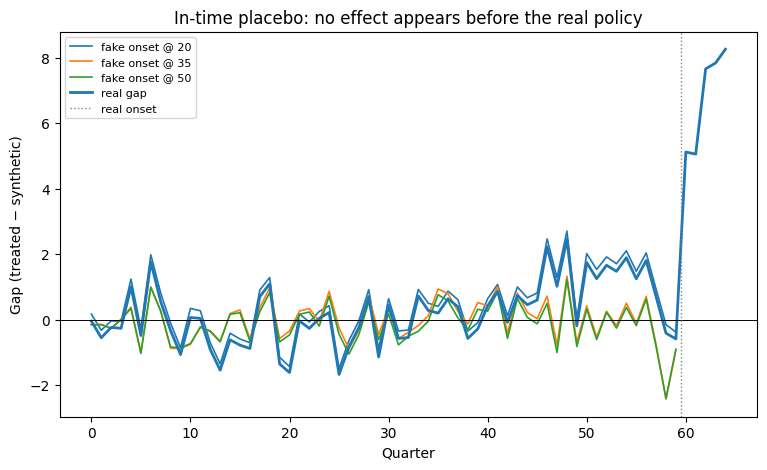

In [10]:
# In-time (backdating) placebo: pretend the policy hit at an earlier quarter and
# check that no "effect" appears before the real onset.
itp = res.in_time_placebo(placebo_periods=[20, 35, 50], n_starts=1)
print(itp[["placebo_period", "placebo_att", "status"]].round(3).to_string(index=False))

# Plot 5: backdated gap paths stay near zero.
itg = res.get_in_time_placebo_gaps()
fig, ax = plt.subplots(figsize=(9, 5))
for pp, sub in itg.groupby("placebo_period"):
    sub = sub.sort_values("period")
    ax.plot(sub["period"], sub["gap"], lw=1.2, label=f"fake onset @ {pp}")
ax.plot(periods, gd["gap"].to_numpy(), color="#1f77b4", lw=2.0, label="real gap")
ax.axhline(0, color="black", lw=0.7)
ax.axvline(59.5, color="gray", ls=":", lw=1, label="real onset")
ax.set_xlabel("Quarter")
ax.set_ylabel("Gap (treated − synthetic)")
ax.set_title("In-time placebo: no effect appears before the real policy")
ax.legend(loc="upper left", fontsize=8)
plt.show()

**Robustness.** Dropping any single donor moves the ATT by at most **≈ 0.76** — the
result does not hinge on one comparison state. And backdating the "policy" to earlier
quarters produces near-zero placebo effects (all `|·| < 1`), versus the real `5`–`9`: the
divergence is specific to the actual onset, not a pre-existing trend.

## Philosophy B — compare across time (conformal)

Philosophy A asks whether the treated state is unusual *among units*. Conformal inference
(CWZ 2021) asks a different question: given **this** state's own time series, is the
post-period gap distinguishable from the pre-period fluctuations, **period by period**?

Under a hypothesized effect path, CWZ subtracts it off, fits a *time-symmetric* proxy
synthetic control (constrained least squares on the raw outcomes over **all** periods — no
`V` matrix; this is what the exactness theory requires, and it differs slightly from the
headline ADH fit), and permutes the residuals over time. We start with the sharp null of
**no effect**.

In [11]:
joint = res.conformal_test(0.0)
print(f"joint conformal test, H0: no effect  ->  p = {joint['p_value']:.4f} "
      f"(|Pi| = {joint['n_perms']} permutations)")

# Sanity: the test should NOT reject the true ramp.
true_ramp = (
    panel[(panel["unit"] == 0) & (panel["treatment"] == 1)]
    .sort_values("period")["true_effect"].to_numpy()
)
print(f"joint conformal test, H0: the TRUE ramp  ->  p = "
      f"{res.conformal_test(true_ramp)['p_value']:.3f}")

joint conformal test, H0: no effect  ->  p = 0.0154 (|Pi| = 65 permutations)
joint conformal test, H0: the TRUE ramp  ->  p = 0.831


The sharp null of no effect is rejected (**p ≈ 0.015**), while the true ramp is not
rejected (large p) — exactly as it should be. Now the payoff: **a confidence interval for
the effect in each post quarter**, by inverting that test over a grid of candidate values.

In [12]:
ci = res.conformal_confidence_intervals(alpha=0.1, scheme="moving_block")
ci_show = ci[["period", "lower", "upper"]].copy()
ci_show["true_effect"] = true_eff[-5:]
print(ci_show.round(2).to_string(index=False))

 period  lower  upper  true_effect
     60   3.91   5.87          5.0
     61   4.50   6.46          6.0
     62   6.56   8.52          7.0
     63   7.45   9.52          8.0
     64   7.94  10.01          9.0


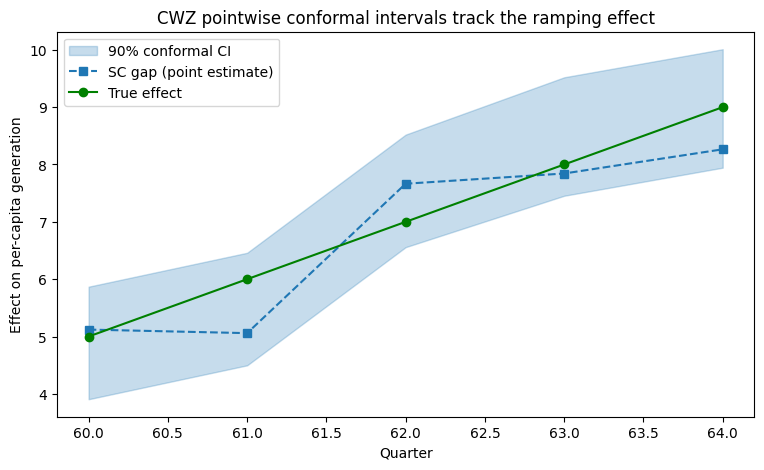

In [13]:
# Plot 6: the per-period conformal CI band (the payoff).
post_periods = ci["period"].to_numpy()
sc_gap_post = gd[gd["phase"] == "post"].sort_values("period")["gap"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(post_periods, ci["lower"], ci["upper"], alpha=0.25, color="#1f77b4",
                label="90% conformal CI")
ax.plot(post_periods, sc_gap_post, "s--", color="#1f77b4", label="SC gap (point estimate)")
ax.plot(post_periods, true_eff[-5:], "o-", color="green", label="True effect")
ax.set_xlabel("Quarter")
ax.set_ylabel("Effect on per-capita generation")
ax.set_title("CWZ pointwise conformal intervals track the ramping effect")
ax.legend(loc="upper left")
plt.show()

**Reading the band.** Each post quarter gets its own 90% interval, and the band
**rises with the ramp**, containing the true effect in every period — without ever assuming
the effect is constant or linear. This is what cross-region permutation could not deliver: a
calibrated, period-by-period uncertainty statement. (Each interval is a 90% interval, so an
occasional period legitimately missing the truth would be expected; here all five contain it.)

For a single-number summary, CWZ also gives a confidence interval for the **average** effect
by collapsing the panel into non-overlapping blocks.

In [14]:
ae = res.conformal_average_effect(alpha=0.1, scheme="moving_block")
print(f"90% CI for the average post-period effect: "
      f"[{ae['lower']:.2f}, {ae['upper']:.2f}]  (true average = 7.0)")
print(f"(collapsed into {ae['n_blocks']} blocks)")

90% CI for the average post-period effect: [6.50, 7.48]  (true average = 7.0)
(collapsed into 13 blocks)


The average-effect interval is **≈ [6.5, 7.5]** — tight, bounded, and bracketing the
true `7.0`. **Practitioner footnote:** this interval works by collapsing the panel into
`T/T* = 13` blocks and permuting them; its resolution is `1/13 ≈ 0.077`, comfortably below
`α = 0.1`. With a *short* pre-period the block count drops, the permutation grid coarsens,
and the interval can become uninformative (the method fails closed to `(-∞, ∞)` rather than
reporting a falsely-precise width). That is precisely why we used a long, 60-quarter
pre-window.

## The two philosophies, side by side

| | Philosophy A (across regions) | Philosophy B (across time) |
|---|---|---|
| Question | Is the treated unit unusual vs *other units*? | Is the gap unusual vs *this unit's own history*? |
| Tools | in-space placebo, Firpo–Possebom set | CWZ test, pointwise CIs, average-effect CI |
| Resolution set by | number of donors (`1/(J+1)`) | number of periods / blocks |
| Output | one p-value; a set for a constant/linear family | per-period intervals; a free-form path p-value |
| Needs | a sizable donor pool | a long pre-period |

Neither dominates. Cross-region permutation is the classic, intuitive check and is robust to
how the within-unit errors are correlated. Over-time conformal is the only one of the two
that gives you a **calibrated interval for each period's effect** without assuming a
parametric shape — invaluable when, as here, the effect evolves.

## Practitioner takeaways

- **Reach for synthetic control** when a single (or a few) units are treated and no untreated
  unit is a credible stand-alone control, but a *weighted blend* of donors can reproduce the
  treated unit's pre-period path. Check the pre-period RMSPE and the predictor-balance table
  before trusting any post-period gap.
- **Don't over-read the weights** — the counterfactual path is identified; the exact weights
  are not.
- **For inference, use both routes.** Report the in-space placebo p-value and a robustness
  pair (leave-one-out + in-time placebo); add CWZ pointwise intervals when stakeholders need
  period-by-period uncertainty, and the average-effect interval for a headline number.
- **Design for the method you'll use:** cross-region permutation wants a sizable donor pool
  (the p-value floor is `1/(J+1)`); conformal inference — especially the average-effect
  interval — wants a long pre-period.

**Extensions not covered here:** folding covariates into the conformal proxy; the `q = 2`/
`q = ∞` conformal norms (we used `q = 1`); the `scheme="iid"` permutation set; and the `cv`/
`inverse_variance` routes for selecting `V`.

**Related tutorials:** [03 — Synthetic DiD](03_synthetic_did.ipynb) (a regression-weighted
cousin) and [10 — TROP](10_trop.ipynb) (a triply-robust panel estimator).

**References:** Abadie, Diamond & Hainmueller (2010, 2015); Firpo & Possebom (2018);
Chernozhukov, Wüthrich & Zhu (2021). Full citations in the project
[references](../references.rst).